In [1]:
%run ./00_setup.ipynb
growth_by_segment = pd.read_parquet(INTERIM_DIR / "growth_by_segment.parquet")

listings      1,061 rows  29 columns
leases        4,302 rows  35 columns
concessions   3,560 rows  18 columns
asking        3,857 rows  14 columns
Columns dropped from leases: ['available_date', 'property_type', 'furnishing', 'smoking', 'cats_allowed', 'dogs_allowed']
leases: 4,302 rows, 33 columns


## 7. External data and reconciliation with the internal trend

### 7.1 Public sources collected (`data/external/`, details in `sources.md`)
| Series | Use | Source |
|---|---|---|
| TAL calculation, unheated dwelling, 2022–2026 | anchor for QC renewals | tal.gouv.qc.ca (official releases) |
| Ontario guideline, 2019–2026 | ON context (The Met exempt, §6.2) | ontario.ca |
| CPI, rent component, QC and ON, monthly (table 18-10-0004-01) | anchor for QC turnovers and Ontario | Statistics Canada |
| CMHC Rental Market Survey 2020–2025 (official tables): **fixed-sample** 2-bedroom rent change, vacancy, turnover premium | alternative anchor (§9.4) + context | CMHC, Rental Market Report data tables |

**No-leakage rule:** to forecast year `Y` as of 31 December `Y−1`, we only use what was published before that date:
CPI up to **November** `Y−1` (released mid-December) and the TAL calculation for `Y−1` (the one for `Y` comes out in January `Y`).
Labelled exception: the central 2026 forecast also uses the 2026 TAL calculation (3.1 %), published in January 2026 (choice explained in §8.5).

### 7.2 Loading and shaping the external series
One row per year × province, every indicator as a fraction.

In [2]:
tal_rates = pd.read_csv(EXTERNAL_DIR / "tal_rent_adjustment.csv")
ontario_guideline = pd.read_csv(EXTERNAL_DIR / "ontario_rent_guideline.csv")
cpi_rent_monthly = pd.read_csv(EXTERNAL_DIR / "statcan_cpi_rent_monthly.csv")
cmhc_official = pd.read_csv(EXTERNAL_DIR / "cmhc_rms_official.csv")

cpi_dates = pd.to_datetime(cpi_rent_monthly.month + "-01")
cpi_rent_monthly["year"] = cpi_dates.dt.year
cpi_rent_monthly["month_num"] = cpi_dates.dt.month
cpi_known = cpi_rent_monthly[cpi_dates <= DATA_CUTOFF]

cpi_annual = (cpi_known.groupby(["geo", "year"]).cpi_rent_index_2002_100.mean()
              .groupby(level="geo").pct_change().rename("cpi_rent_annual"))
cpi_last_known = (cpi_known[cpi_known.month_num == CPI_LAST_KNOWN_MONTH]
                  .set_index(["geo", "year"]).cpi_rent_index_2002_100
                  .groupby(level="geo").pct_change().rename("cpi_rent_nov_yoy"))

external_yearly = pd.concat([cpi_annual, cpi_last_known], axis=1).reset_index().rename(columns={"geo": "province"})
external_yearly = external_yearly.merge(
    tal_rates[["year", "tal_unheated_base_pct"]].assign(province="QC"), on=["province", "year"], how="outer")
external_yearly = external_yearly.merge(
    ontario_guideline[["year", "ontario_guideline_pct"]].assign(province="ON"), on=["province", "year"], how="outer")
external_yearly["tal_rate"] = external_yearly.pop("tal_unheated_base_pct") / PCT
external_yearly["ontario_guideline"] = external_yearly.pop("ontario_guideline_pct") / PCT
# CMHC: fixed-sample 2-bedroom rent change (same "same unit" logic as our measure)
geo_to_province = {geo: province for province, geo in CMHC_GEO_BY_PROVINCE.items()}
cmhc_fixed_sample = (cmhc_official[cmhc_official.metric == "fixed_sample_2br_rent_change"]
                     .assign(province=lambda d: d.geo.map(geo_to_province),
                             cmhc_fixed_sample_2br=lambda d: d.value_pct / PCT)
                     .dropna(subset=["province"])
                     .rename(columns={"survey_year": "year", "published_date": "cmhc_published_date"}))
external_yearly = external_yearly.merge(
    cmhc_fixed_sample[["province", "year", "cmhc_fixed_sample_2br", "cmhc_published_date"]],
    on=["province", "year"], how="left")
external_yearly = external_yearly.sort_values(["province", "year"]).reset_index(drop=True)
(external_yearly.drop(columns="cmhc_published_date").set_index(["province", "year"]).loc[(slice(None), slice(FIRST_ANALYSIS_YEAR, None)), :] * PCT).round(2)

cpi_rent_annual  cpi_rent_nov_yoy  tal_rate  ontario_guideline  cmhc_fixed_sample_2br
province year                                                                                       
ON       2018             1.44              1.60       NaN                NaN                    NaN
         2019             3.80              3.89       NaN                1.8                    NaN
         2020             1.64              1.35       NaN                2.2                    5.2
         2021             1.49              2.28       NaN                0.0                    1.3
         2022             5.58              7.15       NaN                1.2                    4.8
         2023             6.27              5.09       NaN                2.5                    4.0
         2024             6.90              7.37       NaN                2.5                    5.0
         2025             4.30              4.07       NaN                2.5                    3.4
         2026              NaN               NaN       NaN                2.1                    NaN
QC       2018             0.81              1.01       NaN                NaN                    NaN
         2019             1.93              2.34       NaN                NaN                    NaN
         2020             1.20              2.04       NaN                NaN                    3.6
         2021             2.74              1.20       NaN                NaN                    3.9
         2022             3.60              5.30      1.28                NaN                    5.4
         2023             5.88              7.44      2.30                NaN                    7.9
         2024             8.87              8.19      4.00                NaN                    6.3
         2025             7.75              8.28      5.90                NaN                    7.2
         2026              NaN               NaN      3.10                NaN                    NaN

**CMHC market context (never transposed to Équinoxe):** vacancy rate and rent gap between re-let and
not re-let units (2 bedrooms). Vacancy rises in Montréal (1.5 % → 2.9 %) and Ottawa (2.1 % → 3.0 %) between 2023 and 2025.
The market is loosening, which fits with deeper concessions.

In [3]:
cmhc_context = cmhc_official[cmhc_official.metric != "fixed_sample_2br_rent_change"].pivot_table(
    index="survey_year", columns=["metric", "geo"], values="value_pct")
cmhc_context.round(1)

metric      turnover_premium_2br                 vacancy_rate                
geo                       Canada Montreal Ottawa       Canada Montreal Ottawa
survey_year                                                                  
2021                         NaN      NaN    NaN          3.1      3.0    3.4
2022                         NaN      NaN    NaN          1.9      2.0    2.1
2023                         NaN      NaN    NaN          1.5      1.5    2.1
2024                        19.9      9.9   23.2          2.2      2.1    2.6
2025                        16.2      NaN   22.1          3.1      2.9    3.0

### 7.3 Reconciliation: internal trend vs external indicators
For each segment and year, we put our internal contract growth next to the relevant external indicator, and compute the gap.

In [4]:
internal_contract = (growth_by_segment[growth_by_segment.rent_basis == "contract"]
                     .pivot_table(index=["province", "lease_year"], columns="lease_type", values="median")
                     .reset_index().rename(columns={"lease_year": "year"}))
reconciliation = internal_contract.merge(external_yearly, on=["province", "year"], how="left")
reconciliation = reconciliation[reconciliation.year >= FIRST_ANALYSIS_YEAR]
reconciliation["gap_renewal_vs_tal"] = reconciliation.renewal - reconciliation.tal_rate
reconciliation["gap_turnover_vs_cpi"] = reconciliation.turnover - reconciliation.cpi_rent_annual
reconciliation["gap_all_vs_cmhc"] = (reconciliation.renewal + reconciliation.turnover) / 2 - reconciliation.cmhc_fixed_sample_2br
display_cols = ["province", "year", "renewal", "turnover", "tal_rate", "ontario_guideline",
                "cpi_rent_annual", "cmhc_fixed_sample_2br", "gap_renewal_vs_tal", "gap_turnover_vs_cpi", "gap_all_vs_cmhc"]
reconciliation_view = reconciliation[display_cols].set_index(["province", "year"])
(reconciliation_view * PCT).round(2)

renewal  turnover  tal_rate  ontario_guideline  cpi_rent_annual  cmhc_fixed_sample_2br  gap_renewal_vs_tal  gap_turnover_vs_cpi  \
province year                                                                                                                                    
ON       2024     2.97      4.94       NaN                2.5             6.90                    5.0                 NaN                -1.96   
         2025     6.25      8.96       NaN                2.5             4.30                    3.4                 NaN                 4.66   
QC       2018     3.00      1.03       NaN                NaN             0.81                    NaN                 NaN                 0.22   
         2019     2.55      1.21       NaN                NaN             1.93                    NaN                 NaN                -0.72   
         2020     3.43      2.05       NaN                NaN             1.20                    3.6                 NaN                 0.85   
         2021     4.77      3.52       NaN                NaN             2.74                    3.9                 NaN                 0.77   
         2022     5.69      4.22      1.28                NaN             3.60                    5.4                4.41                 0.62   
         2023     2.58      1.85      2.30                NaN             5.88                    7.9                0.28                -4.03   
         2024     2.94      4.84      4.00                NaN             8.87                    6.3               -1.06                -4.04   
         2025     6.43      8.98      5.90                NaN             7.75                    7.2                0.53                 1.23   

               gap_all_vs_cmhc  
province year                   
ON       2024            -1.04  
         2025             4.20  
QC       2018              NaN  
         2019              NaN  
         2020            -0.86  
         2021             0.24  
         2022            -0.45  
         2023            -5.69  
         2024            -2.41  
         2025             0.51

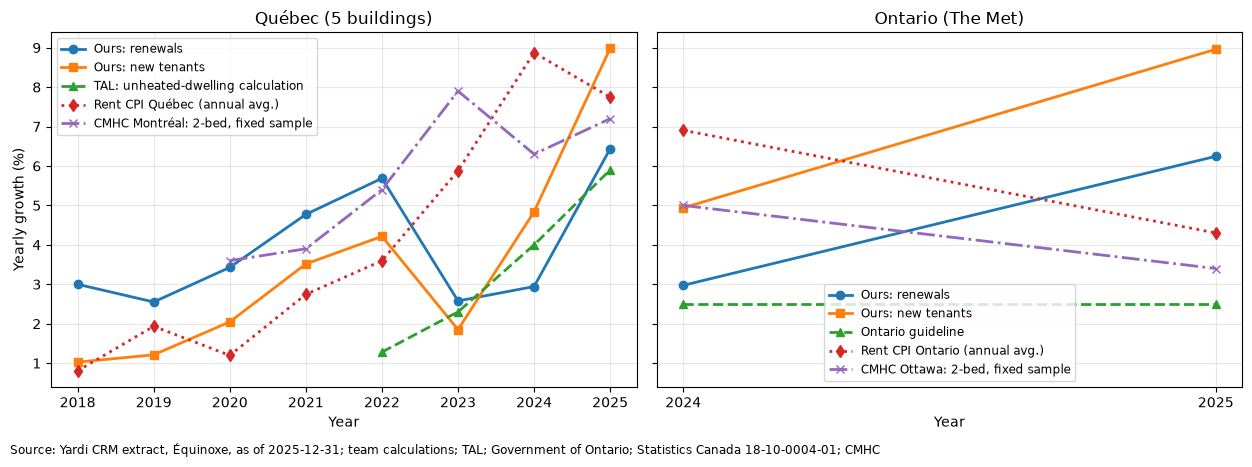

In [5]:
fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE, sharey=True)
qc = reconciliation[reconciliation.province == "QC"]
axes[0].plot(qc.year, qc.renewal * PCT, "o-", label="Ours: renewals")
axes[0].plot(qc.year, qc.turnover * PCT, "s-", label="Ours: new tenants")
axes[0].plot(qc.year, qc.tal_rate * PCT, "^--", label="TAL: unheated-dwelling calculation")
axes[0].plot(qc.year, qc.cpi_rent_annual * PCT, "d:", label="Rent CPI Québec (annual avg.)")
axes[0].plot(qc.year, qc.cmhc_fixed_sample_2br * PCT, "x-.", label="CMHC Montréal: 2-bed, fixed sample")
axes[0].set_title("Québec (5 buildings)")
on = reconciliation[reconciliation.province == "ON"]
axes[1].plot(on.year, on.renewal * PCT, "o-", label="Ours: renewals")
axes[1].plot(on.year, on.turnover * PCT, "s-", label="Ours: new tenants")
axes[1].plot(on.year, on.ontario_guideline * PCT, "^--", label="Ontario guideline")
axes[1].plot(on.year, on.cpi_rent_annual * PCT, "d:", label="Rent CPI Ontario (annual avg.)")
axes[1].plot(on.year, on.cmhc_fixed_sample_2br * PCT, "x-.", label="CMHC Ottawa: 2-bed, fixed sample")
axes[1].set_title("Ontario (The Met)")
for ax in axes:
    ax.set_xlabel("Year")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(fontsize="small")
axes[0].set_ylabel("Yearly growth (%)")
add_source(fig, SOURCE_CRM + "; TAL; Government of Ontario; Statistics Canada 18-10-0004-01; CMHC")
plt.tight_layout()
plt.show()

### 7.4 What the reconciliation tells us
- **QC renewals vs TAL:** since 2023 the gap is small (≈ ±1 pt: 2023 ≈ 2.6 % vs 2.3 %; 2025 ≈ 6.4 % vs 5.9 %). In 2022 the gap is
  large (≈ 5.7 % vs 1.28 %): the TAL calculation is based on past expenses and reacted late to the inflation shock, while
  landlords were already asking for more. The TAL is therefore a **relevant but non-binding anchor** for renewals.
- **QC turnovers vs QC rent CPI:** turnovers follow the rent CPI with about a one-year lag (CPI 2024 ≈ 8.9 % → turnovers 2025 ≈ 9.0 %).
  That is why the anchor for a turnover in `Y` is the rent CPI known at the end of `Y−1`.
- **Ontario:** The Met's renewals (≈ 3 % in 2024, ≈ 6.3 % in 2025) are above the guideline (2.5 %), which fits the post-2018 exemption.
  So the guideline is **not** used as an anchor; the Ontario rent CPI is.
- **CMHC, fixed sample (2 bedrooms):** Montréal +7.9 % (2023), +6.3 % (2024), +7.2 % (2025); Ottawa +4.0 %, +5.0 %, +3.4 %.
  It is the public measure closest to ours (the same units from one year to the next), and it brackets our turnovers / renewals well.
  Our favourite finding here: the press reported "+10.7 % in Ottawa in 2024", a figure on the average rent of the **whole** stock (new buildings included),
  while the fixed sample gives +5.0 %. **The mix effect from §3 shows up in public statistics too.**
- **CMHC context:** vacancy up in 2025 (Montréal 2.9 %, Ottawa 3.0 %) and a high turnover premium in Ottawa (≈ 22 %):
  a loosening market, which fits concessions staying deep in 2026. Context only, never turned into an occupancy rate for Équinoxe.
- **Indicators we left out:** the guideline for The Met (exempt); CMHC average rents by bedroom count (stock mix, not the same units).

In [6]:
external_yearly.to_parquet(INTERIM_DIR / "external_yearly.parquet")
reconciliation.to_parquet(INTERIM_DIR / "reconciliation.parquet")